In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fit_data = np.zeros((100,701))
gens_complete = np.zeros(100)
for i in range(100):
    bar = np.loadtxt('./%s/evol.dat'%i,usecols=1)[::2]
    gens = len(bar)
    gens_complete[i] = gens
    fit_data[i,0:gens] = bar
gens_complete = gens_complete.astype(int)
max_fit = np.max(fit_data[:,-1])
print(np.where(fit_data[:,-1]==max_fit)[0],max_fit)

[88] 1.07128


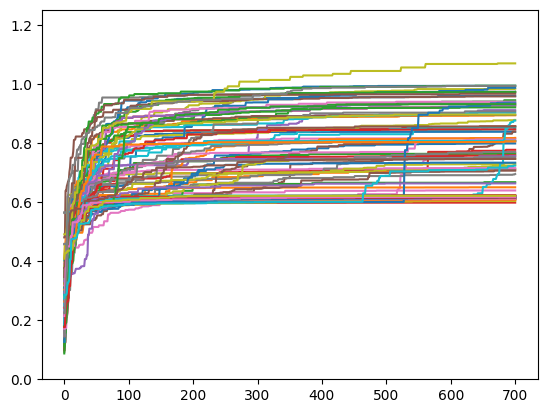

In [3]:
plt.ylim(0,2*0.6267)
for i in range(100):
    plt.plot(range(gens_complete[i]),fit_data[i,0:gens_complete[i]])

In [4]:
genomes = np.zeros((100,36))
for i in range(100):
    with open('./%s/evol.dat'%i) as f:
        k = 0
        for line in f:
            line = line.replace('\n', '')
            line = np.array([float(x) for x in line.split(' ')])
            # Convert elements to desired data type (e.g., int)
            if k%2 != 0:
                genomes[i] = line
            k += 1

print(genomes)

[[ 0.83395   1.76251   0.479147 ...  1.22284   3.06032   8.46758 ]
 [ 1.45588   1.71176   1.38063  ... -6.52259   4.71165  -9.26572 ]
 [ 0.456641  0.674099  0.753705 ...  6.66      8.26572   3.4032  ]
 ...
 [ 1.88882   0.761009  0.671005 ...  6.73279  -5.09505   9.20083 ]
 [ 1.82682   1.62788   0.24779  ...  9.78486   9.18523  -2.05273 ]
 [ 1.18019   1.22439   0.723423 ... -0.85581  -3.5533   -6.72917 ]]


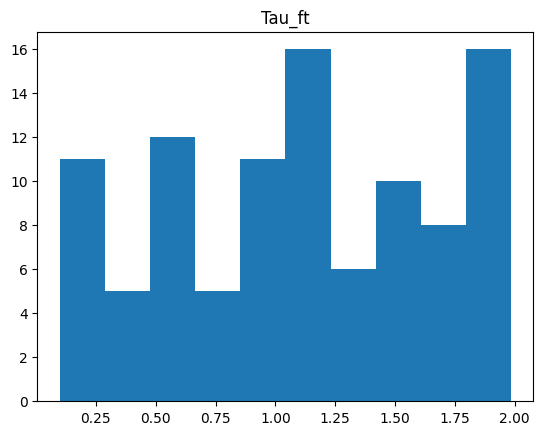

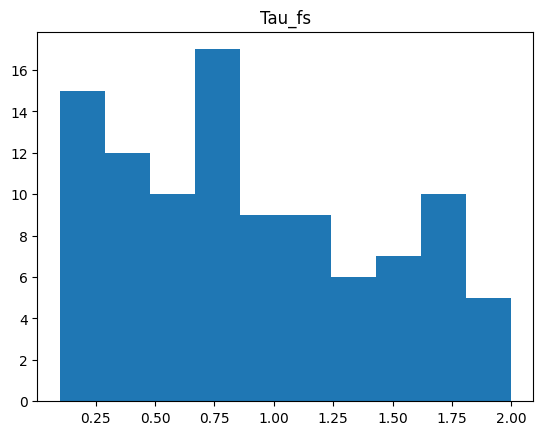

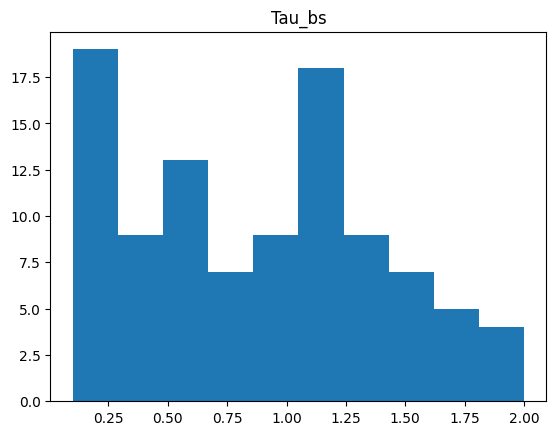

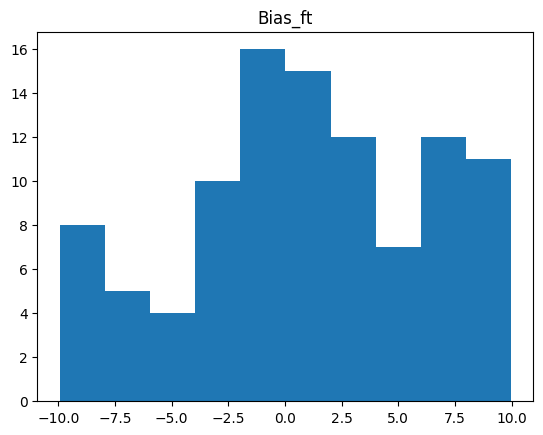

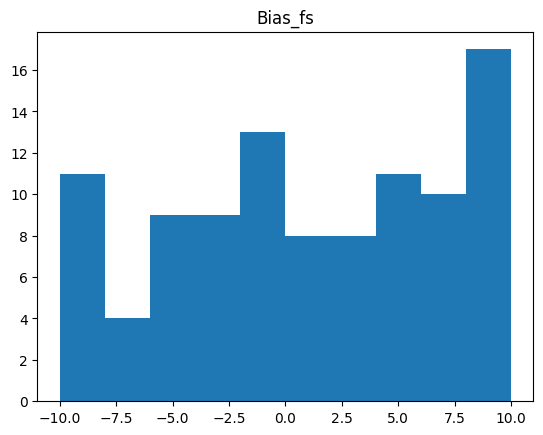

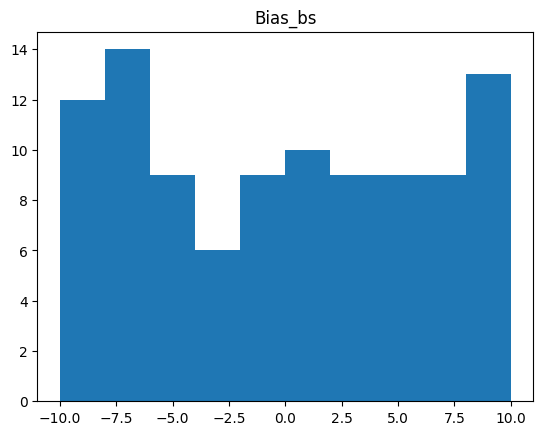

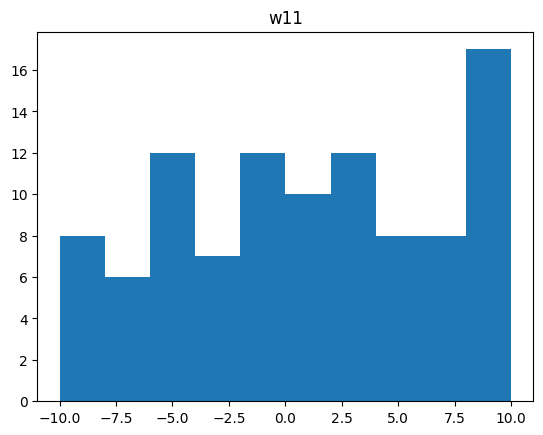

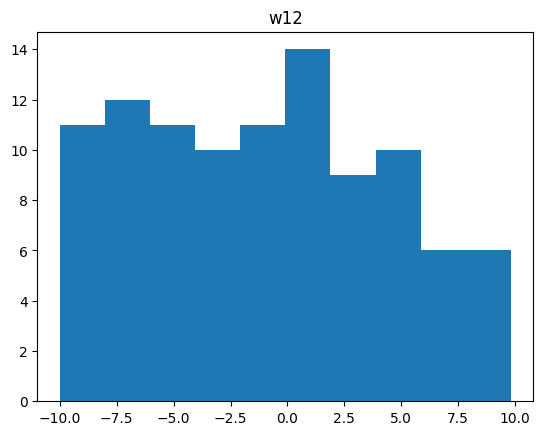

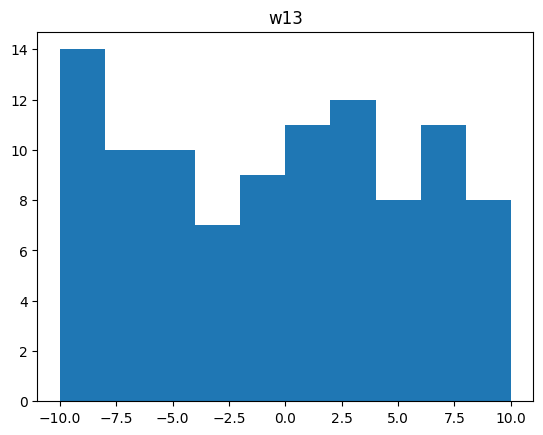

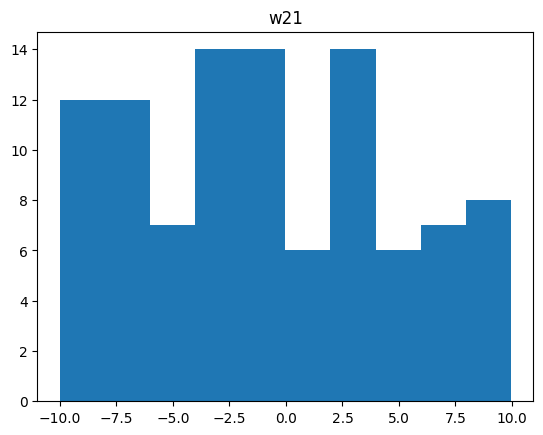

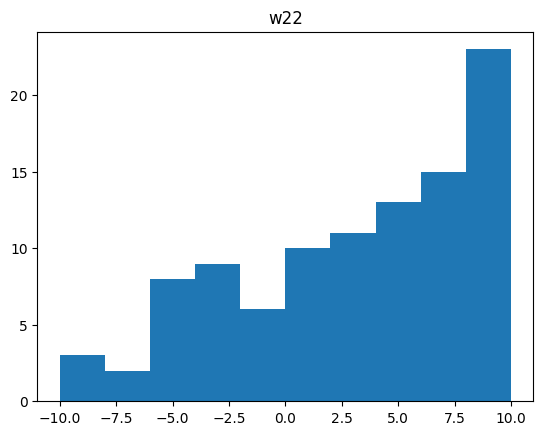

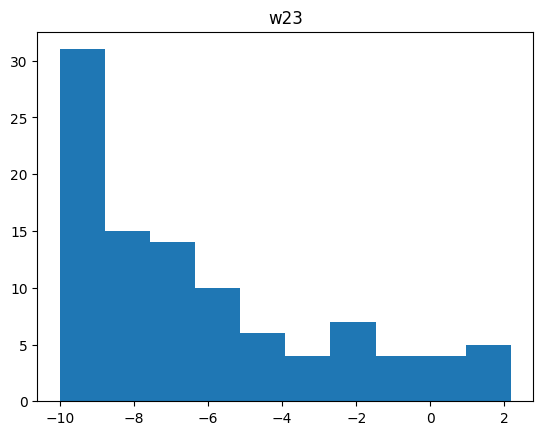

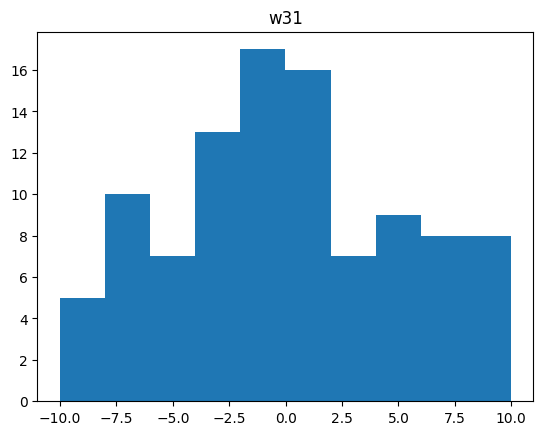

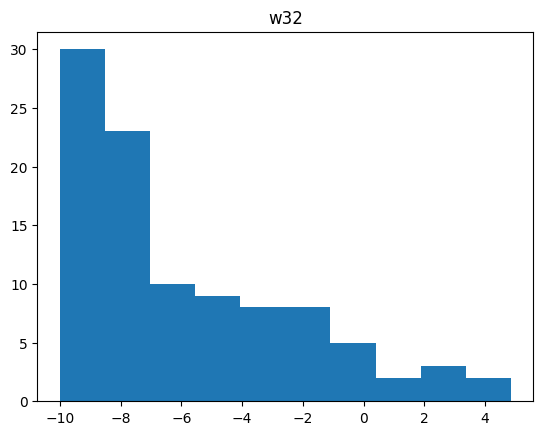

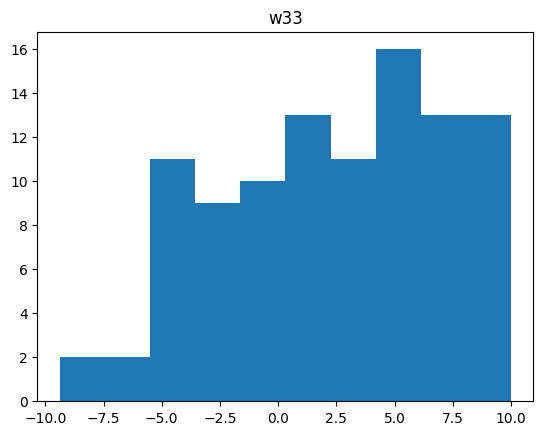

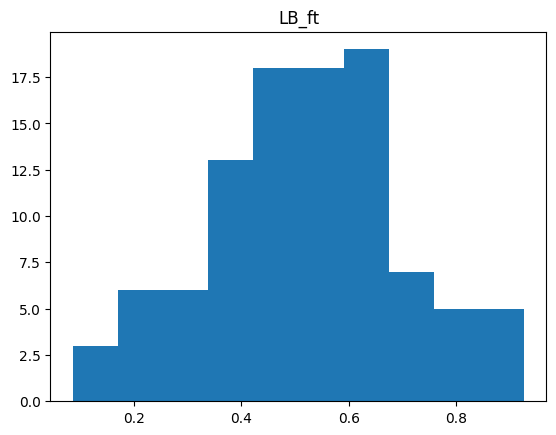

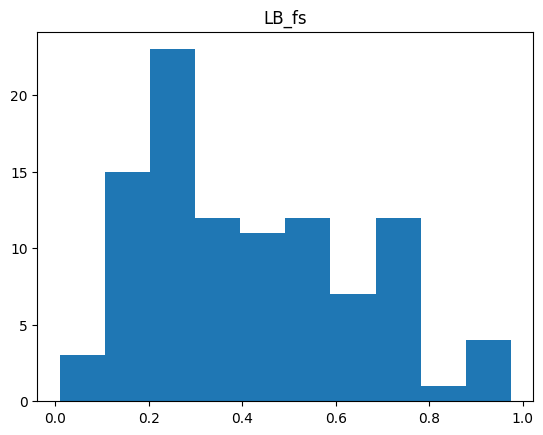

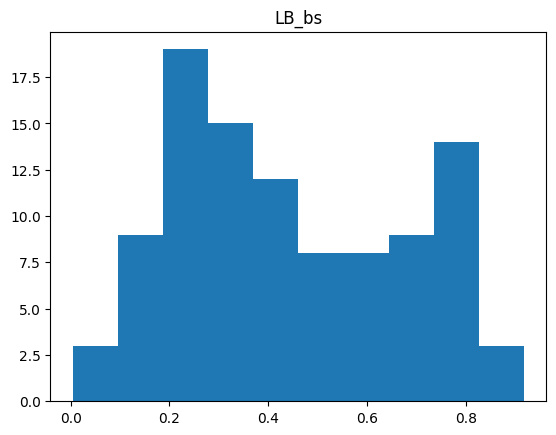

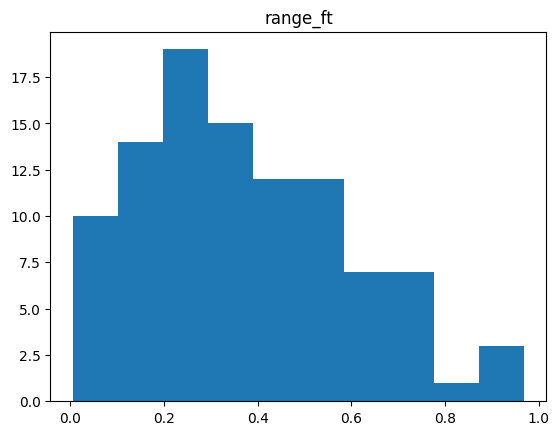

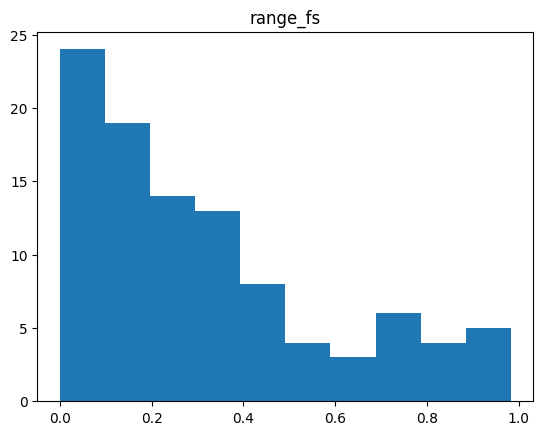

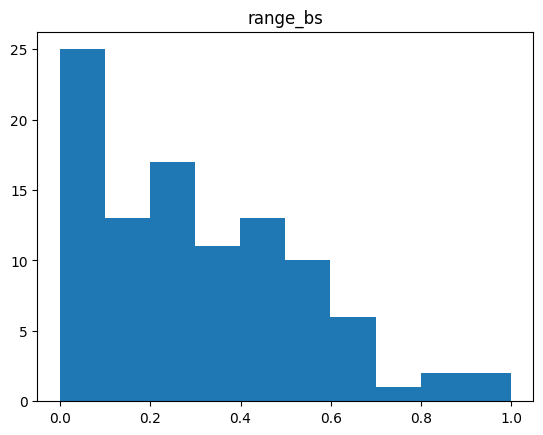

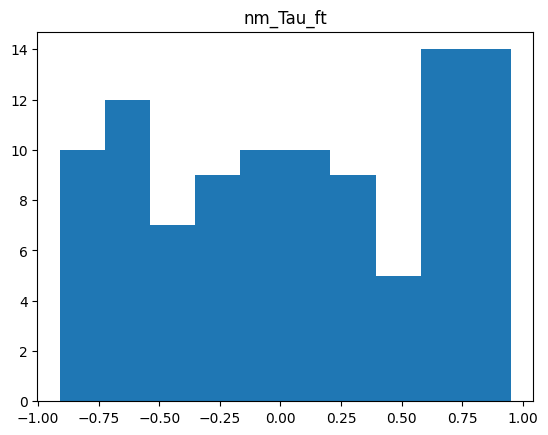

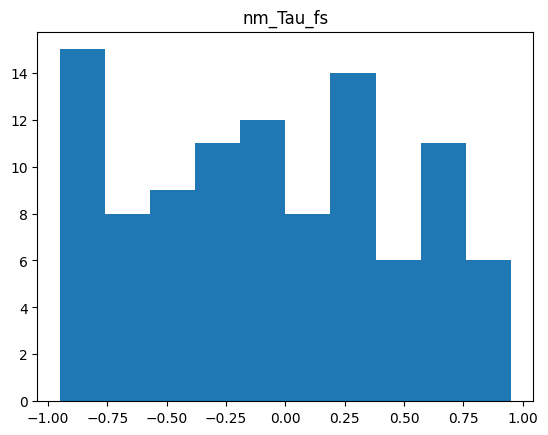

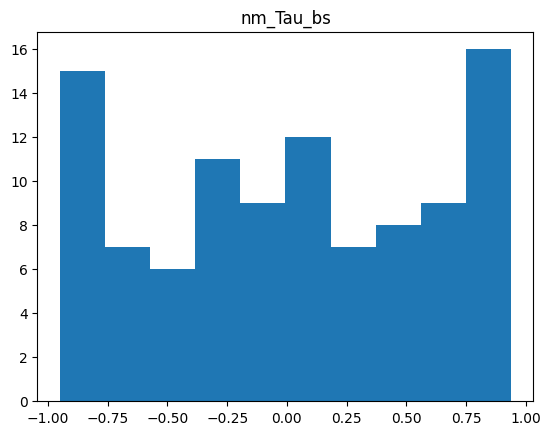

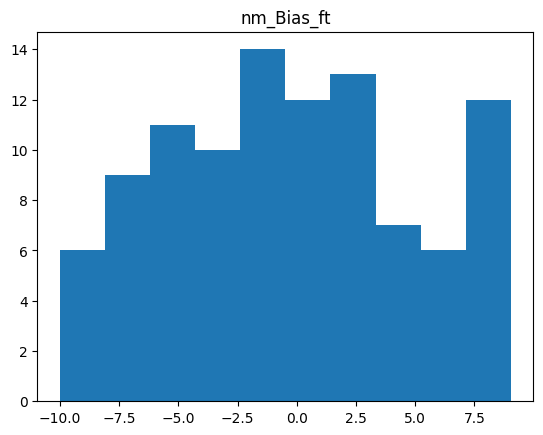

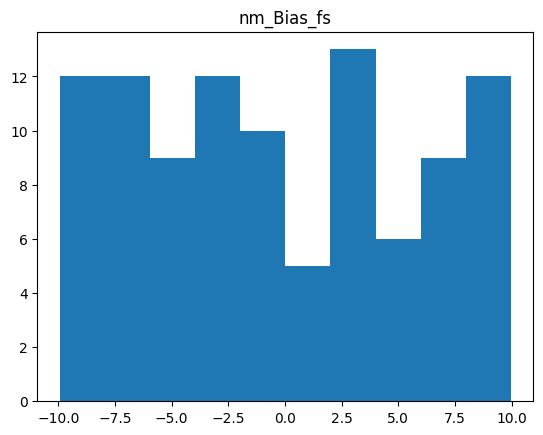

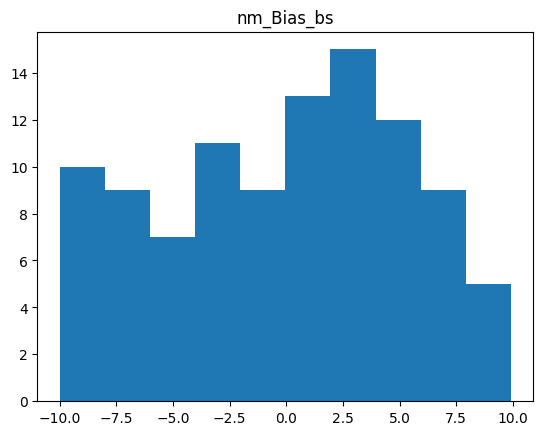

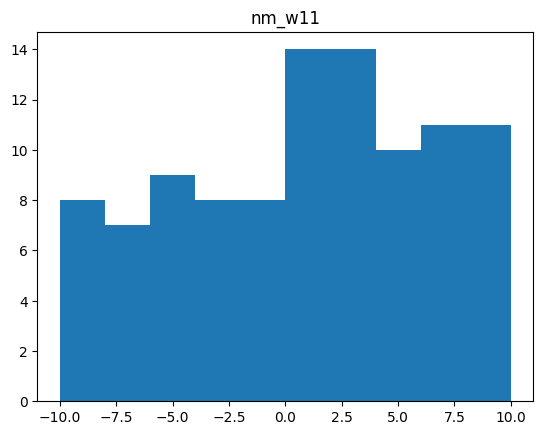

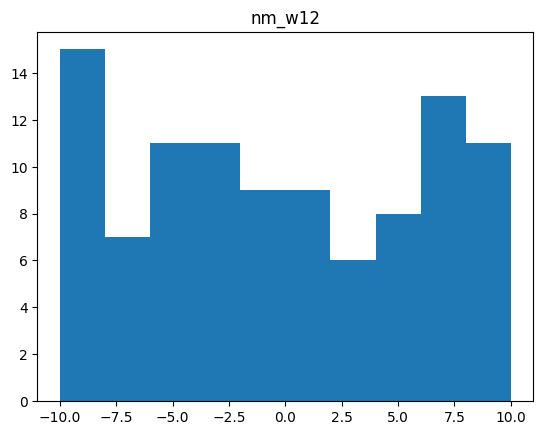

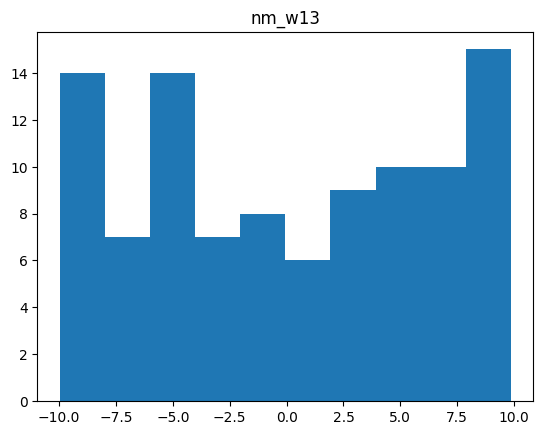

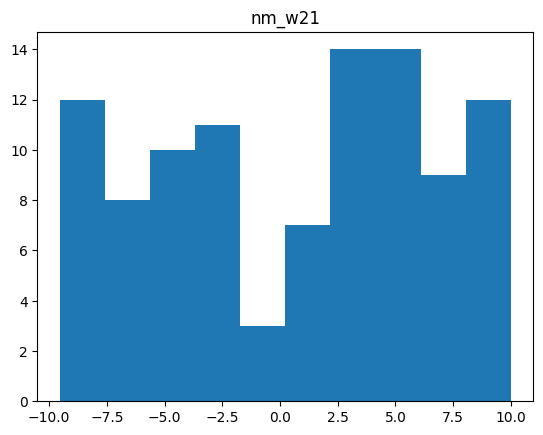

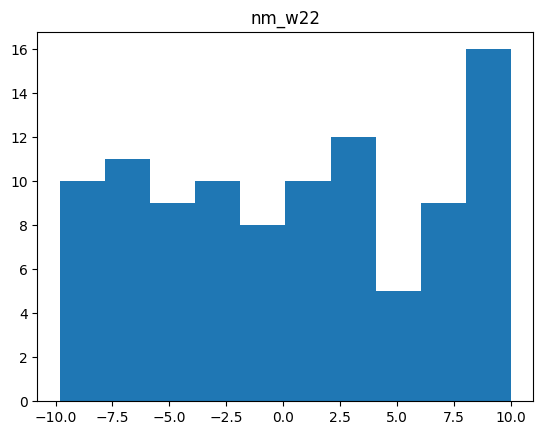

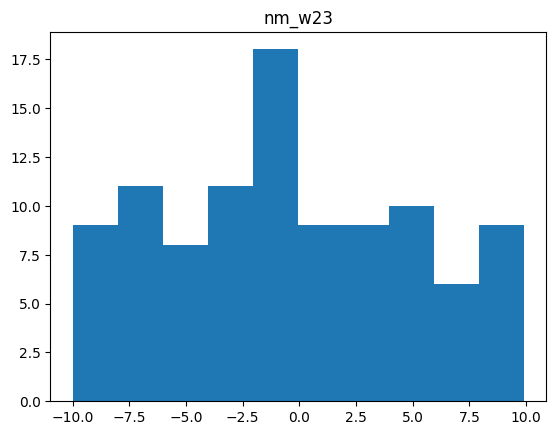

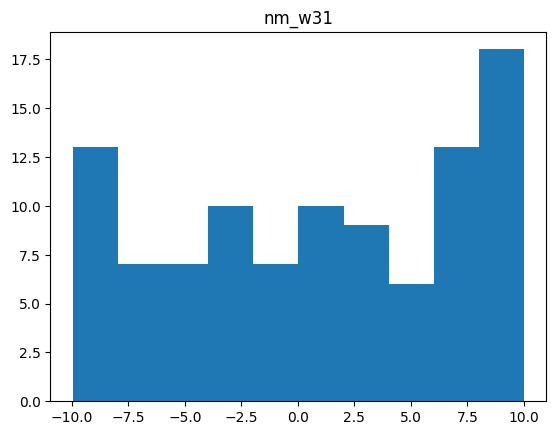

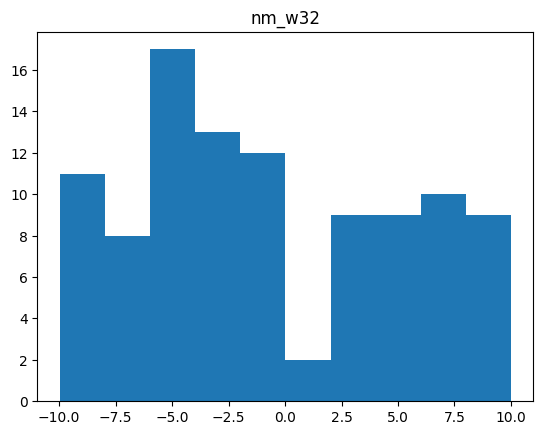

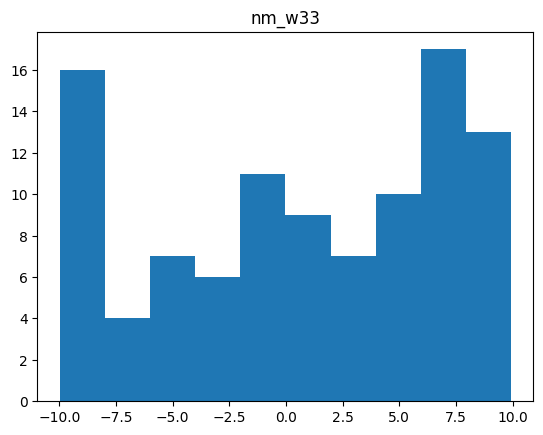

In [5]:
titles = ['Tau_ft','Tau_fs','Tau_bs','Bias_ft','Bias_fs','Bias_bs','w11','w12','w13','w21','w22','w23','w31','w32','w33','LB_ft','LB_fs','LB_bs','range_ft','range_fs','range_bs',
          'nm_Tau_ft','nm_Tau_fs','nm_Tau_bs','nm_Bias_ft','nm_Bias_fs','nm_Bias_bs','nm_w11','nm_w12','nm_w13','nm_w21','nm_w22','nm_w23','nm_w31','nm_w32','nm_w33',]
for i in range(36):
    plt.hist(genomes[:,i])
    plt.title(titles[i])
    plt.show()

In [31]:
#best individual number 88 parameter tracking:
partrack = np.loadtxt('../neuralparameters.dat')
statestrack = np.loadtxt('../neuraltimeseries.dat')
homeostatic_limits = np.array([[0.327306,0.960517],[0.327515,0.408658],[0.227657,0.439364]])

In [63]:
#calcaverages for each neuron's activity
st= -600000
end = -515000
beh1 = [st,st+45000]
beh2 = [end-35000,end]
avgs_beh1 = statestrack[beh1[0]:beh1[1]]
avgs_beh2 = statestrack[beh2[0]:beh2[1]]
avgs_beh1 = np.average(avgs_beh1,axis=0)
avgs_beh2 = np.average(avgs_beh2,axis=0)
print(avgs_beh1,avgs_beh2)

[0.81317189 0.34945637 0.62802669] [0.7489718  0.71080653 0.26978078]


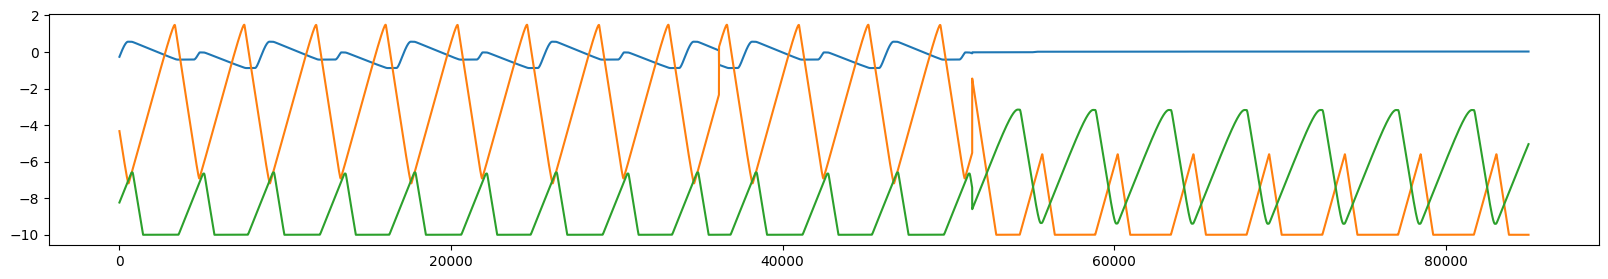

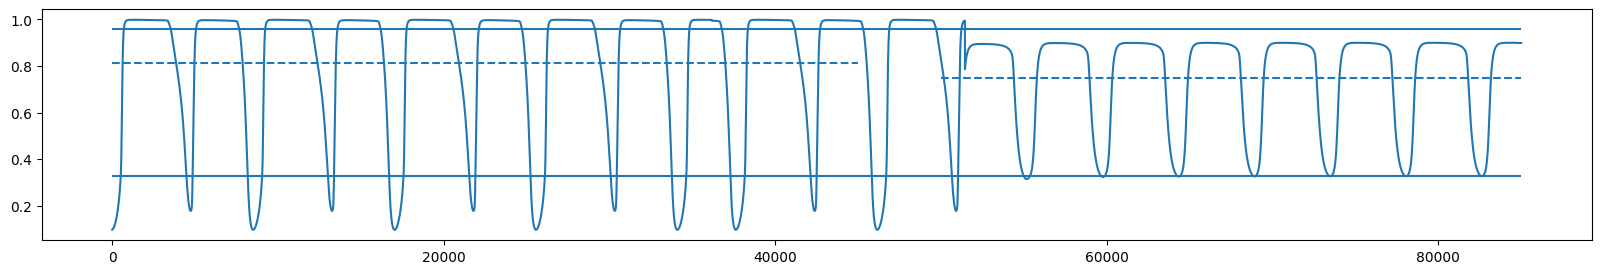

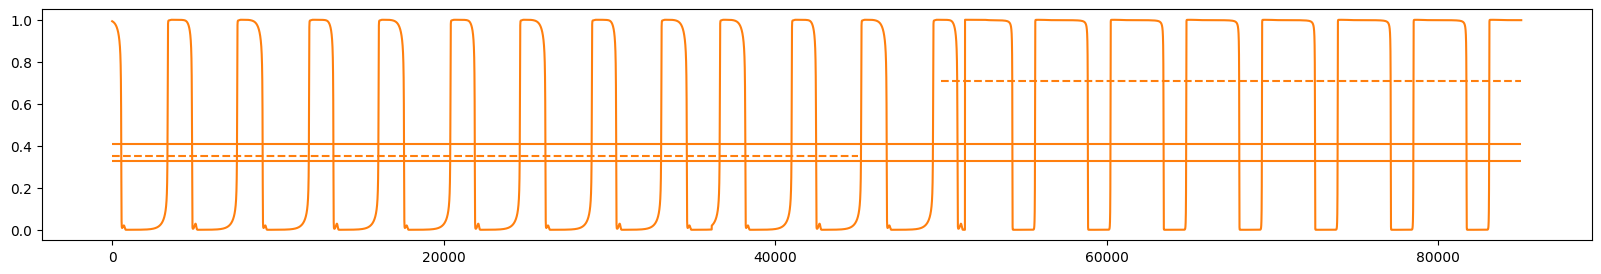

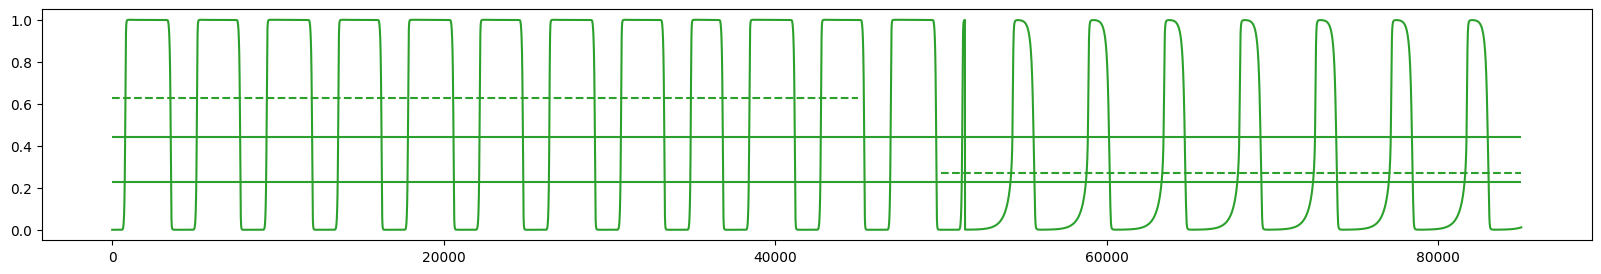

In [64]:

plt.rcParams['figure.figsize'] = (20,3)
for i in range(len(partrack[0])):
    plt.plot(partrack[st:end,i])
plt.show()

colors = ['tab:blue','tab:orange','tab:green']
for i in range(len(statestrack[0])):
    plt.plot(statestrack[st:end,i],color=colors[i])
    plt.hlines(homeostatic_limits[i],0,len(statestrack[st:end]),color=colors[i])
    plt.hlines(avgs_beh1[i],0,45000,color=colors[i],linestyles='dashed')
    plt.hlines(avgs_beh2[i],len(statestrack[st:end])-35000,len(statestrack[st:end]),color=colors[i],linestyles='dashed')
    plt.show()

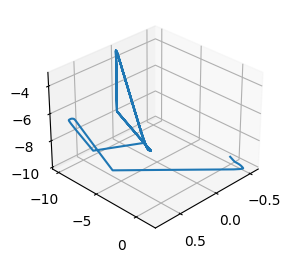

In [30]:
fig = plt.figure()
ax = fig.add_subplot(1,1,1,projection='3d')
ax.view_init(elev=30, azim=45)
st = -35000
end = -10000
ax.plot(partrack[st:end,0],partrack[st:end,1],partrack[st:end,2])